# Assignment 3
This exercise has two parts:

- Part A consists of mandatory exercises; you need to complete these and hand in your answers to be able to partake in the exam. This part also provides you with an impression of the minimum knowledge level necessary to pass the exam.
- Part B consists of additional exercises. These repeat a concept that is covered in Part A or help to broaden or deepen your understanding of some of the topics.

## Assignment by
Lan Stare, s1169977

Aaron Ritz, s1170346

(we also forgot to add Aaron's name to the previous assignment!!)

# A: Mandatory Exercises
Below you will find the mandatory exercises for Week 3 of the course Data Mining and Machine Learning.

### **Exercise 1** - Data Exploration

In this part of the exercise we will consider two data sets related to red and white variants of the Portuguese "Vinho Verde" wine[1]. The data has been downloaded from http://archive.ics.uci.edu/ml/datasets/Wine+Quality.

#### **1.1** - Preprocessing
**1.1.a**
Install the ucimlrepo library using pip, and use it to load this winedata into a dataframe (https://github.com/uci-ml-repo/ucimlrepo). Vinho Verde has id 186.

In [2]:
### import library ###
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Load the wine dataset
data = fetch_ucirepo(id=186)

Now, running the cell below should give you an overview of the dataset you just downloaded.

In [3]:
data

{'data': {'ids': None,
  'features':       fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
  0               7.4              0.70         0.00             1.9      0.076   
  1               7.8              0.88         0.00             2.6      0.098   
  2               7.8              0.76         0.04             2.3      0.092   
  3              11.2              0.28         0.56             1.9      0.075   
  4               7.4              0.70         0.00             1.9      0.076   
  ...             ...               ...          ...             ...        ...   
  6492            6.2              0.21         0.29             1.6      0.039   
  6493            6.6              0.32         0.36             8.0      0.047   
  6494            6.5              0.24         0.19             1.2      0.041   
  6495            5.5              0.29         0.30             1.1      0.022   
  6496            6.0              0.21         0.38

**1.1.b** As you may have noticed, there is a lot of extra data included in this dataframe. For now we just want to extract the values for all 11 attributes outlined on the UCI website. To do this, first access the data stored in the "data" attribute of the dataframe. From within the "data" attribute, extract the information contained in the "features" attribute. Save this new, isolated data into a variable called wine_data.

In [4]:
wine_data = data.data.features

On the website above, we can see a description of the wine dataset. It is always good to do a sanity check when loading such data. Some research tells me there should be 6497 rows of data, distributed over 11 attributes. The assert statement below only runs when we indeed see this shape!

In [5]:
assert(wine_data.shape == (6497,11))

#### **1.2** - Inspecting the data
Besides making sure that the data is loaded correctly, it is also good practice to inspect whether the data itself makes sense. We can do this by, for example, visualizing the distribution of the attributes in our dataset. The wine dataset contains many observations that can be considered outliers. Can we visually recognize this?

Plot a box plot and a histogram for each attribute to visualize the outliers in the data set. Use subplotting to nicely visualize these plots. Add titles to each subplot so it's easy to see which attribute is depicted where. Make sure that each attribute is visualized on an applicable scale.

**Helpful tip:**
 + *You can use the function `matplotlib.pyplot.subplots()` to plot several plots in one figure. A simple example an be found at: https://matplotlib.org/2.0.2/examples/pylab_examples/subplots_demo.html, take a look at the 2D subplot specifically. There is also an example of a subplot in the first assignment. If you're handy, you can, and should, devise a for loop which fills up the subplot area!*


**Make sure to take a look at the documentation of functions before you try to use them!**

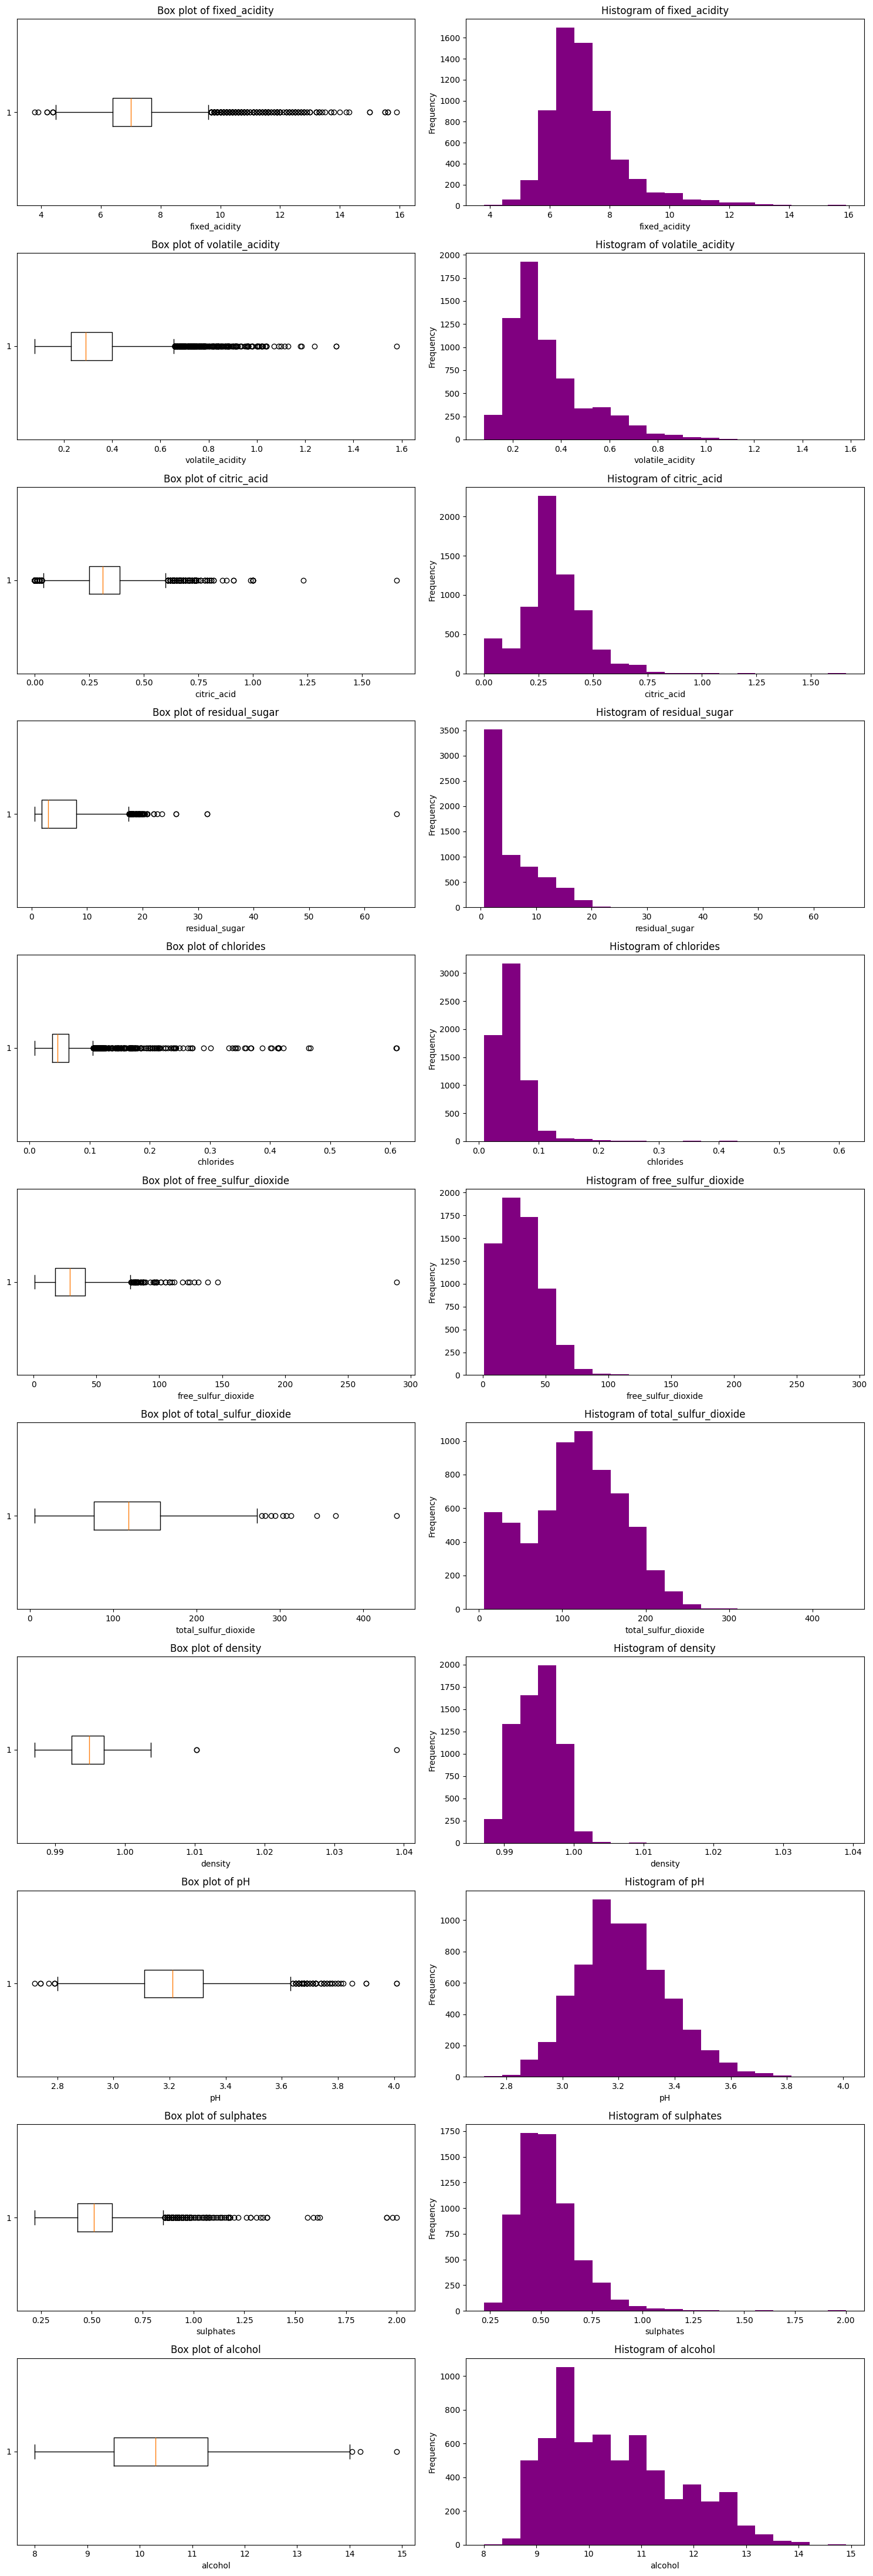

In [41]:
import matplotlib.pyplot as plt

num_features = wine_data.shape[1] #How many features we have so we can iterate over them

fig, axes = plt.subplots(nrows=num_features, ncols=2, figsize=(15, num_features * 4)) # This way we can see box plots and histograms side by side and are scaled by trial and error to fit well :)

for i, col in enumerate(wine_data.columns):
    axes[i, 0].boxplot(wine_data[col], vert=False) #Horisontal boxplots to see data better
    axes[i, 0].set_title(f'Box plot of {col}')
    axes[i, 0].set_xlabel(col)
    
    axes[i, 1].hist(wine_data[col], bins=20, color='purple') 
    axes[i, 1].set_title(f'Histogram of {col}')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout() #So the titles don't overlap
plt.show()


ANSWER:
We can visually recognise the outliers in boxplots. They are represented by the black circles.

#### **1.3** - Removing the outliers
Observing the data is a good first step to finding unexpected and possibly erroneous data points, however, often we still need to confirm such suspicions with some outside knowledge of the data. For this dataset a lot is known about the attributes that we are inspecting.

The data has the following attributes:

| #   |  Attribute      | Unit |
| --- |:--------------- |:---- |
| 1   | Fixed acidity (tartaric) | g/dm3 |
| 2   | Volatile acidity (acetic) | g/dm3 |
| 3   | Citric acid | g/dm3 |
| 4   | Residual sugar | g/dm3 |
| 5   | Chlorides | g/dm3 |
| 6   | Free sulfur dioxide | mg/dm3 |
| 7   | Total sulfur dioxide | mg/dm3 |
| 8   | Density | g/cm3 |
| 9   | pH | pH |
| 10  | Sulphates | g/dm3 |
| 11  | Alcohol | % vol. |
| 12  | Quality score | 0-10 |

Attributes 1-11 are based on physicochemical tests and attribute 12 on human judging. From prior knowledge we expect volatile acidity to be around 0-2 g/dm3, density to be close to 1 g/cm3, and alcohol percentage to be somewhere between 5-20% vol.

The data set has many observations that can be considered outliers given these constraints, and in order to carry out analyses it is important to remove the corrupt observations. We can safely identify the outliers for these attributes, searching for values which are a factor of 10 greater than the largest we expect. In the case of alcohol, we will **set the limit not to a factor 10, but to what is physically possible.**

**1.3.a**
Identify outliers for volatile acidity, density, and alcohol percentage, all based on the criteria above, and remove them from the data set. This means that you should remove the entire sample from the dataset, not just clear that attribute!. Save the filtered data to `wine_data_filtered`. After filtering your data, standardize the data. Save your standardized and filtered data to `wine_data_filtered_standardized`.

**Helpful tips:**
 + *You can use logical indexing to easily make a new dataset, where the outliers are removed. This is much easier, and faster than methods like dropping, or selecting using a for loop or list comprehension. For more information, see: https://docs.scipy.org/doc/numpy-1.13.0/user/basics.indexing.html Take a look at the -Boolean or "mask" index arrays- section.*
 + *It is advisable to perform some sanity checks when removing parts of the data. Check for yourself how many samples are removed in each filtering step!*
 + *For standardization, use the StandardScaler included in the scikit-learn package, see: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html. This is initially not the easiest way to standardize data, but it will save a lot of time in future experiments and your own project if you master the scikit-learn API!*

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

**1.3.b** Now that we have removed the outliers, we will compare the distributions with the original data. Plot new box plots and histograms for the three attributes that you just filtered. Compare these new box plots to the corresponding attributes of the original, unfiltered, data by plotting the original plots side by side with the new plots.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

### **Exercise 2** - Attributes and Transformations
When fitting models to a dataset, it is important to both understand the attributes your data already has, and how you can transform these attributes into attributes that might be useful to you. Let's look into this a bit more!

#### **2.1** -  Attribute Classification
Classify the following attributes as binary, discrete, or continuous. Also classify
them as qualitative (nominal or ordinal) or quantitative (interval or ratio).

**a.** Time in terms of AM or PM.

**b.** Brightness as measured by a light meter.

**c.** Angles as measured in degrees between 0 and 360.

**d.** Ability to pass light in terms of the following values: opaque,translucent,transparent.

**e.** Density of a substance in grams per cubic centimeter.

#### Answers

**a.** Binary, nominal

**b.** Continuous, interval (because I think that 2x higher meter doesn't mean 2x brighter)

**c.** Continuous, ratio

**d.** Discrete, ordinal (because transparent materials pass *more* light than translucent which pass *more* light than opaque)

**e.** Continuous, ratio (if only integers are allowed then it's discrete)

#### **2.2** - TF-IDF
Consider a document-term matrix, where ${tf}_{ij}$ is the frequency of the ith word
(term) in the jth document and m is the number of documents. Consider the
**variable transformation** that is defined by

$$\text{idf'}_{ij} = \text{tf}_{ij} \times \log \frac{m}{df_i}$$

where $df_i$ is the number of documents in which the ith term appears, which
is known as the document frequency of the term. This transformation is
known as the inverse document frequency transformation.

**a.** What is the effect of this transformation if a term occurs in one document?

**b.** What if it occurs in every document?

**c.** What might be the purpose of this transformation?

#### Answers

**a.** The variable transformation is equal to the frequency of the i-th term in the jth document multiplied by the factor $\log{m}$. This means that the value of the variable transformation is bigger than the frequency of the term in the jth document.

**b.** The transformation is 0, since the log of 1 is 0.

**c.** The purpose of this transformation is to reduce the importance of terms that appear in many documents and increase the importance of those that appear in fewer ones. This way we can reduce the noise in our data (by removing the common words like "the", "and", etc.).

#### **2.3** - Transformations
Assume that we apply a square root transformation to a ratio attribute x to
obtain the new attribute x∗. As part of your analysis, you identify an interval
(a, b) in which x∗ has a linear relationship to another attribute y.

**a.** What is the corresponding interval (a, b) in terms of x?

**b.** Give an equation that relates y to x.

#### Answer
**a.** The corresponding interval in terms of x is $(a^2, b^2)$.

**b.** $$ \sqrt{x} = k*y + c \implies x = (k*y + c)^2 = k^2 * y^2 + 2kcy + c^2 $$ This means that x and y have a quadratic relationship.

### **Exercise 3** - Sampling
**a.** You are given a set of $m$ objects that is divided into $K$ groups, where the $i$ th
group is of size $m_i$. If the goal is to obtain a sample of size $n < m$, what are some of the essential differences between the following two sampling schemes? (Assume sampling
with replacement.)

**i.** We randomly select $n \times m_i/m$ elements from each group.

**ii.** We randomly select $n$ elements from the data set, without regard for the
group to which an object belongs.

**b.** Have a look at the documentation for pandas.DataFrame.sample (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) do you see if this uses method (i) or (ii)? Is there a way to make it use the other method (Googling might help)?

#### Answer
**a.** In ii. we might lose the representation of some groups, whereas in i. we make sure that each group, that contains at least 1 object, is represented. The problem with i. is that if some groups are very small, we might end up with a sample that isn't representative of the whole dataset.

**b.** The method used is ii. We can make it use method i. by using the *stratify* parameter of the *train_test_split* function from scikit-learn. We can first split the data into train and test sets using *train_test_split*, and then use the *sample* method on the train set to get a stratified sample.

### **Exercise 4** - Similarity
It can be useful to be able to compare several items in your dataset with one another. There are many ways to go about this, let's look at a few.

#### **4.1** - Measures
For the following vectors, x and y, calculate the cosine, correlation, Euclidean and Jaccard similarity or distance
measure.

**a.** $x = (1, 1, 1, 1), y = (2, 2, 2, 2)$

**b.** $x = (0, 1, 0, 1), y = (1, 0, 1, 0)$

**d.** $x = (1, 1, 0, 1, 0, 1), y = (1, 1, 1, 0, 0, 1)$

YOUR ANSWERS HERE

#### **4.2** - transformations
Given a similarity measure $f$ with values in the interval $[0,1]$

**a.** Describe a tranformation to transform $f$ into a similarity measure with values spanning the entire interval $[0,\infty]$

**b.** Describe a transformation to transform $f$ into a dissimilarity measure with values spanning the entire interval $[0,\infty]$

For both questions, provide us with an explit formula using $f$!

YOUR ANSWERS HERE

## Part B

### Exercise 5
Let's look back at the wine dataset from exercise 1. Pick 5 items from the dataset (either using [:5] or something similar, or using the .sample() method) and compute the similarity/distance metrics from exercise 3.1 for all of them.

In [ ]:
### YOUR ANSWERS HERE ###

YOUR ANSWERS HERE

### Exercise 6
This exercise compares and contrasts some similarity and distance measures.

**a.** For binary data, the L1 distance corresponds to the Hamming distance;
that is, the number of bits that are different between two binary vectors.
The Jaccard similarity is a measure of the similarity between two binary
vectors. Compute the Hamming distance and the Jaccard similarity between the following two binary vectors.

x = 0101010001

y = 0100011000

**b.** Which approach, Jaccard or Hamming distance, is more similar to the
Simple Matching Coefficient, and which approach is more similar to the
cosine measure? Explain. (Note: The Hamming measure is a distance,
while the other three measures are similarities, but don’t let this confuse
you.)

Many sciences rely on observation instead of (or in addition to) designed
experiments. Compare the data quality issues involved in observational science
with those of experimental science and data mining.

YOUR ANSWERS HERE

### Exercise 7
Show that the set difference metric given by
$$d(A, B) = size(A − B) + size(B − A)$$
satisfies the metric axioms given on page 97 of TTSK. $A$ and $B$ are sets and $A − B$ is
the set difference.

YOUR ANSWERS HERE

### Exercise 8
Answer question 25 from TTSK

YOUR ANSWERS HERE

# Handing in
Hand in the filled-in notebook:
- Make sure your names and student-numbers are mentioned at the appropriate location at the top of this file.
- Make sure you wrote a serious attempt for all exercises in part A
- Make sure the notebook is named groupnumber_assignment1.ipynb

When you are confident all of this is correctly done, one of you can hand in the exercises in Brightspace!